# 🤖 Superstore – 5 Bước Training AI Dự báo Lợi nhuận
---
| Mục | Nội dung |
|---|---|
| **Dataset** | `../data/Superstore_clean.csv` – 9,994 đơn hàng (2011–2014) |
| **Target** | `Profit` (Lợi nhuận) |
| **Split** | **80% Train / 20% Test** |
| **CV** | 5-Fold Cross-Validation (hiện từng fold) |
| **Models** | LinearRegression · RandomForest · GradientBoosting |
| **Output** | Dự báo Profit 3 tháng tới |

> Pipeline chuẩn 5 bước: **Thu thập → Tiền xử lý → Huấn luyện → Đánh giá → Dự báo**


## ⚙️ Import thư viện

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110

PALETTE = {'navy':'#1b365d','teal':'#008080','red':'#d9534f',
           'gold':'#e8a838','grey':'#6c757d','green':'#2e7d32'}
print("✔ Import hoàn tất!")


✔ Import hoàn tất!


---
## 📂 BƯỚC 1 – Thu thập & Tiền xử lý Dữ liệu
*(Data Collection & Preprocessing)*


In [2]:
# 1.1 Đọc dữ liệu
DATA_PATH = '../data/Superstore_clean.csv'
df_raw = pd.read_csv(DATA_PATH)
print(f"Shape gốc: {df_raw.shape[0]:,} dòng × {df_raw.shape[1]} cột")
df_raw['Order Date'] = pd.to_datetime(df_raw['Order Date'], dayfirst=False)
print(f"Khoảng thời gian: {df_raw['Order Date'].min().date()} → {df_raw['Order Date'].max().date()}")
df_raw.head(3)


Shape gốc: 9,994 dòng × 26 cột
Khoảng thời gian: 2011-01-04 → 2014-12-31


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Ship Lead Time (Days),Profit Status,Year,Month,Quarter
0,1,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136,3,Profit,2013,11,4
1,2,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820,3,Profit,2013,11,4
2,3,CA-2013-138688,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714,4,Profit,2013,6,2


In [3]:
# 1.2 Bảng thống kê dữ liệu thô
print("=== BẢNG THỐNG KÊ DỮ LIỆU GỐC ===")
stats = df_raw[['Sales','Discount','Quantity','Profit']].describe().round(2)
display(stats)

# Missing values
missing = df_raw.isnull().sum()
missing_df = pd.DataFrame({'Cột': missing.index, 'Missing': missing.values,
                            'Tỷ lệ (%)': (missing.values/len(df_raw)*100).round(2)})
print("\n=== MISSING VALUES ===")
display(missing_df[missing_df['Missing'] > 0] if missing_df['Missing'].sum() > 0
        else pd.DataFrame({'Kết quả': ['✅ Không có missing values']}))


=== BẢNG THỐNG KÊ DỮ LIỆU GỐC ===


,Sales,Discount,Quantity,Profit
count,9994.00,9994.00,9994.00,9994.00
mean,229.86,0.16,3.79,28.66
std,623.25,0.21,2.23,234.26
min,0.44,0.00,1.00,-6599.98
25%,17.28,0.00,2.00,1.73
50%,54.49,0.20,3.00,8.67
75%,209.94,0.20,5.00,29.36
max,22638.48,0.80,14.00,8399.98



=== MISSING VALUES ===


,Kết quả
0,✅ Không có missing values


In [4]:
# 1.3 Chọn features & encoding
FEATURES     = ['Sales', 'Discount', 'Quantity', 'Category', 'Region']
TARGET       = 'Profit'
NUMERIC_FEAT = ['Sales', 'Discount', 'Quantity']
CAT_FEAT     = ['Category', 'Region']

df = df_raw[FEATURES + [TARGET, 'Order Date']].dropna().copy()
df.sort_values('Order Date', inplace=True)
df.reset_index(drop=True, inplace=True)

X = df[FEATURES].copy()
y = df[TARGET].values

# Pipeline preprocessing
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), NUMERIC_FEAT),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_FEAT),
], remainder='drop')

# Bảng tóm tắt preprocessing
summary_step1 = pd.DataFrame({
    'Thành phần'   : ['Tổng mẫu', 'Features đầu vào', 'Features số',
                       'Features phân loại (OHE)', 'Target variable'],
    'Giá trị'      : [f"{len(df):,}", ', '.join(FEATURES),
                       ', '.join(NUMERIC_FEAT), ', '.join(CAT_FEAT), TARGET],
    'Xử lý'        : ['—', '—', 'StandardScaler', 'OneHotEncoder', '—'],
})
print("\n=== BẢNG TÓM TẮT PREPROCESSING ===")
display(summary_step1)



=== BẢNG TÓM TẮT PREPROCESSING ===


,Thành phần,Giá trị,Xử lý
0,Tổng mẫu,"9,994",—
1,Features đầu vào,"Sales, Discount, Quantity, Category, Region",—
2,Features số,"Sales, Discount, Quantity",StandardScaler
3,Features phân loại (OHE),"Category, Region",OneHotEncoder
4,Target variable,Profit,—


---
## ✂️ BƯỚC 2 – Chia tập Train / Test (80% / 20%)
*(Train-Test Split)*

> **Lý do 80/20**: 80% dữ liệu để mô hình học, 20% để kiểm tra khả năng dự đoán trên dữ liệu chưa thấy.  
> Dùng `shuffle=False` để giữ nguyên thứ tự thời gian.


=== BẢNG CHIA DỮ LIỆU TRAIN / TEST ===


,Tập dữ liệu,Số mẫu,Tỷ lệ,Khoảng thời gian
0,🟦 Train (Học),7995,80%,2011-01-04 → 2014-07-19
1,🟥 Test (Thi),1999,20%,2014-07-19 → 2014-12-31
2,Tổng,9994,100%,2011-01-04 → 2014-12-31


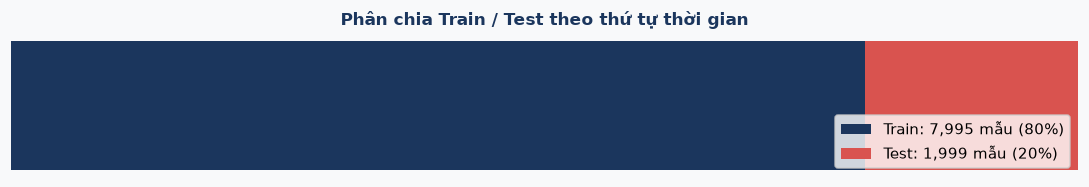

✔ Train: 7,995 mẫu | Test: 1,999 mẫu


In [5]:
# Chia 80/20 theo thứ tự thời gian (không shuffle)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False)

# Bảng thông tin split
split_df = pd.DataFrame({
    'Tập dữ liệu'  : ['🟦 Train (Học)', '🟥 Test (Thi)', 'Tổng'],
    'Số mẫu'       : [len(X_train), len(X_test), len(X)],
    'Tỷ lệ'        : ['80%', '20%', '100%'],
    'Khoảng thời gian': [
        f"{df['Order Date'].iloc[0].date()} → {df['Order Date'].iloc[len(X_train)-1].date()}",
        f"{df['Order Date'].iloc[len(X_train)].date()} → {df['Order Date'].iloc[-1].date()}",
        f"{df['Order Date'].iloc[0].date()} → {df['Order Date'].iloc[-1].date()}"
    ]
})
print("=== BẢNG CHIA DỮ LIỆU TRAIN / TEST ===")
display(split_df)

# Biểu đồ minh hoạ split
fig, ax = plt.subplots(figsize=(10, 1.8), facecolor='#f8f9fa')
ax.barh(0, len(X_train), color=PALETTE['navy'], height=0.5, label=f'Train: {len(X_train):,} mẫu (80%)')
ax.barh(0, len(X_test),  left=len(X_train), color=PALETTE['red'], height=0.5, label=f'Test: {len(X_test):,} mẫu (20%)')
ax.set_xlim(0, len(X)); ax.axis('off')
ax.legend(loc='lower right', fontsize=10)
ax.set_title('Phân chia Train / Test theo thứ tự thời gian',
             fontweight='bold', fontsize=11, color=PALETTE['navy'])
plt.tight_layout(); plt.show()
print(f"✔ Train: {len(X_train):,} mẫu | Test: {len(X_test):,} mẫu")


---
## 🏋️ BƯỚC 3 – Huấn luyện Mô hình (5-Fold Cross-Validation)
*(Model Training)*

> **5-Fold CV trên tập Train**: Chia Train thành 5 phần — mỗi vòng dùng 4 phần học, 1 phần kiểm tra nội bộ.  
> Mục đích: đánh giá độ ổn định của mô hình trước khi test trên tập 20%.


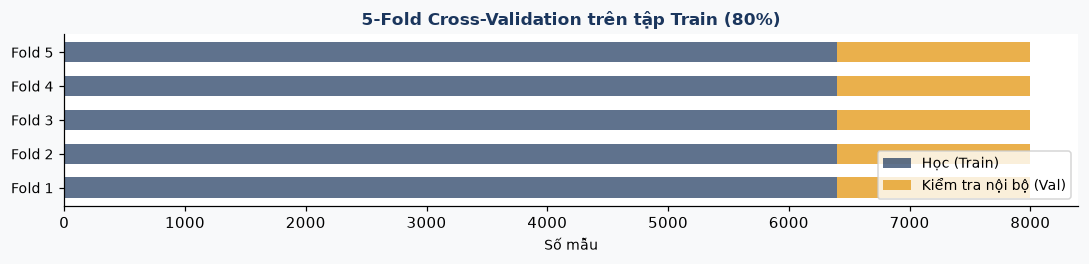

In [6]:
# Định nghĩa 3 mô hình
MODEL_CONFIGS = {
    'Linear Regression' : LinearRegression(),
    'Random Forest'     : RandomForestRegressor(n_estimators=200, max_depth=10,
                              min_samples_leaf=5, random_state=42, n_jobs=-1),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=200,
                              learning_rate=0.05, max_depth=5,
                              subsample=0.8, random_state=42),
}
N_FOLDS = 5
kf = KFold(n_splits=N_FOLDS, shuffle=False)

# Minh hoạ 5-Fold
fig, ax = plt.subplots(figsize=(10, 2.5), facecolor='#f8f9fa')
n_train = len(X_train)
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train)):
    ax.barh(fold, len(tr_idx), color=PALETTE['navy'], alpha=0.7, height=0.6,
            label='Học (Train)' if fold==0 else '')
    ax.barh(fold, len(val_idx), left=len(tr_idx), color=PALETTE['gold'],
            alpha=0.9, height=0.6, label='Kiểm tra nội bộ (Val)' if fold==0 else '')
ax.set_yticks(range(N_FOLDS))
ax.set_yticklabels([f'Fold {i+1}' for i in range(N_FOLDS)], fontsize=9)
ax.set_xlabel('Số mẫu', fontsize=9)
ax.set_title('5-Fold Cross-Validation trên tập Train (80%)',
             fontweight='bold', fontsize=11, color=PALETTE['navy'])
ax.legend(loc='lower right', fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()


In [7]:
# ── Huấn luyện từng mô hình, hiển thị KẾT QUẢ TỪNG FOLD ──
all_results = {}

for model_name, base_model in MODEL_CONFIGS.items():
    print(f"\n{'='*62}")
    print(f"  🔧 MÔ HÌNH: {model_name}")
    print(f"{'='*62}")
    print(f"  {'Fold':<6} {'Train MAE':>10} {'Val MAE':>10} {'Val RMSE':>10} {'Val R²':>8}")
    print(f"  {'-'*50}")

    pipe = Pipeline([('prep', preprocessor), ('model', base_model)])
    fold_records = []

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train), start=1):
        Xtr  = X_train.iloc[tr_idx]; ytr = y_train[tr_idx]
        Xval = X_train.iloc[val_idx]; yval = y_train[val_idx]

        pipe.fit(Xtr, ytr)
        pred_tr  = pipe.predict(Xtr)
        pred_val = pipe.predict(Xval)

        tr_mae   = mean_absolute_error(ytr, pred_tr)
        val_mae  = mean_absolute_error(yval, pred_val)
        val_rmse = np.sqrt(mean_squared_error(yval, pred_val))
        val_r2   = r2_score(yval, pred_val)

        fold_records.append({'Fold': f'Fold {fold}',
                              'Train MAE': tr_mae, 'Val MAE': val_mae,
                              'Val RMSE': val_rmse, 'Val R²': val_r2})
        print(f"  Fold {fold}  {tr_mae:>10.2f} {val_mae:>10.2f} "
              f"{val_rmse:>10.2f} {val_r2:>8.4f}")

    fold_df = pd.DataFrame(fold_records)
    avg_row = {'Fold': '📊 TRUNG BÌNH',
               'Train MAE': fold_df['Train MAE'].mean(),
               'Val MAE':   fold_df['Val MAE'].mean(),
               'Val RMSE':  fold_df['Val RMSE'].mean(),
               'Val R²':    fold_df['Val R²'].mean()}
    fold_df = pd.concat([fold_df, pd.DataFrame([avg_row])], ignore_index=True)

    print(f"  {'-'*50}")
    print(f"  Avg   {avg_row['Train MAE']:>10.2f} {avg_row['Val MAE']:>10.2f} "
          f"{avg_row['Val RMSE']:>10.2f} {avg_row['Val R²']:>8.4f}")

    all_results[model_name] = {'fold_df': fold_df, 'pipe': pipe,
                                'avg_mae':  avg_row['Val MAE'],
                                'avg_rmse': avg_row['Val RMSE'],
                                'avg_r2':   avg_row['Val R²']}

print("\n✔ Huấn luyện 5-Fold hoàn tất cho cả 3 mô hình!")



  🔧 MÔ HÌNH: Linear Regression
  Fold    Train MAE    Val MAE   Val RMSE   Val R²
  --------------------------------------------------


  Fold 1       58.98      67.40     273.65  -0.7447
  Fold 2       57.34      56.18     144.13   0.3571
  Fold 3       58.29      54.94     149.30   0.4217
  Fold 4       56.46      56.06     248.32   0.3173
  Fold 5       57.14      57.35     198.32   0.4403
  --------------------------------------------------
  Avg        57.64      58.38     202.74   0.1584

  🔧 MÔ HÌNH: Random Forest
  Fold    Train MAE    Val MAE   Val RMSE   Val R²
  --------------------------------------------------


  Fold 1       22.98      34.30     222.48  -0.1532


  Fold 2       24.34      24.04      80.12   0.8014


  Fold 3       23.87      26.59     102.25   0.7288


...

  Fold 1       16.59      33.31     268.62  -0.6811


  Fold 2       17.02      24.76      82.35   0.7901


  Fold 3       17.24      29.19     132.11   0.5472


  Fold 4       17.19      27.23     171.44   0.6746


  Fold 5       17.47      24.82      71.03   0.9282
  --------------------------------------------------
  Avg        17.10      27.86     145.11   0.4518

✔ Huấn luyện 5-Fold hoàn tất cho cả 3 mô hình!


In [8]:
# Bảng chi tiết từng fold cho từng mô hình
print("=== BẢNG KẾT QUẢ TỪNG FOLD – CHI TIẾT ===\n")
for model_name, res in all_results.items():
    print(f"  ► {model_name}")
    fmt_df = res['fold_df'].copy()
    for col in ['Train MAE','Val MAE','Val RMSE']:
        fmt_df[col] = fmt_df[col].apply(lambda v: f"${v:,.2f}")
    fmt_df['Val R²'] = fmt_df['Val R²'].apply(lambda v: f"{v:.4f}")
    display(fmt_df)
    print()


=== BẢNG KẾT QUẢ TỪNG FOLD – CHI TIẾT ===

  ► Linear Regression


,Fold,Train MAE,Val MAE,Val RMSE,Val R²
0,Fold 1,$58.98,$67.40,$273.65,-0.7447
1,Fold 2,$57.34,$56.18,$144.13,0.3571
2,Fold 3,$58.29,$54.94,$149.30,0.4217
3,Fold 4,$56.46,$56.06,$248.32,0.3173
4,Fold 5,$57.14,$57.35,$198.32,0.4403
5,📊 TRUNG BÌNH,$57.64,$58.38,$202.74,0.1584



  ► Random Forest


,Fold,Train MAE,Val MAE,Val RMSE,Val R²
0,Fold 1,$22.98,$34.30,$222.48,-0.1532
1,Fold 2,$24.34,$24.04,$80.12,0.8014
2,Fold 3,$23.87,$26.59,$102.25,0.7288
3,Fold 4,$23.17,$29.98,$227.91,0.4249
4,Fold 5,$23.37,$28.00,$149.16,0.6834
5,📊 TRUNG BÌNH,$23.54,$28.58,$156.38,0.4971



  ► Gradient Boosting


,Fold,Train MAE,Val MAE,Val RMSE,Val R²
0,Fold 1,$16.59,$33.31,$268.62,-0.6811
1,Fold 2,$17.02,$24.76,$82.35,0.7901
2,Fold 3,$17.24,$29.19,$132.11,0.5472
3,Fold 4,$17.19,$27.23,$171.44,0.6746
4,Fold 5,$17.47,$24.82,$71.03,0.9282
5,📊 TRUNG BÌNH,$17.10,$27.86,$145.11,0.4518


---
## 📊 BƯỚC 4 – Đánh giá Mô hình trên tập Test (20%)
*(Model Evaluation)*

> Đây là bài **"thi"** thật sự — mô hình gặp dữ liệu chưa thấy bao giờ.


In [9]:
# Đánh giá final trên tập Test 20%
print("=== BẢNG ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST (20%) ===\n")

test_records = []
for model_name, res in all_results.items():
    pipe = res['pipe']
    pipe.fit(X_train, y_train)        # Re-train trên toàn bộ 80% train
    pred_test = pipe.predict(X_test)
    mae   = mean_absolute_error(y_test, pred_test)
    rmse  = np.sqrt(mean_squared_error(y_test, pred_test))
    r2    = r2_score(y_test, pred_test)
    all_results[model_name]['test_pred'] = pred_test
    all_results[model_name]['test_mae']  = mae
    all_results[model_name]['test_rmse'] = rmse
    all_results[model_name]['test_r2']   = r2
    test_records.append({
        'Mô hình'          : model_name,
        'MAE (sai lệch tb)': f"${mae:,.2f}",
        'RMSE'             : f"${rmse:,.2f}",
        'R² Score'         : f"{r2:.4f}",
        'Giải thích'       : f"Giải thích {r2*100:.1f}% phương sai Profit",
    })

test_df = pd.DataFrame(test_records)
display(test_df)

# Chọn mô hình tốt nhất
best_name = min(all_results, key=lambda k: all_results[k]['test_rmse'])
print(f"\n🏆 Mô hình tốt nhất: [{best_name}]")
print(f"   Test MAE  = ${all_results[best_name]['test_mae']:,.2f}")
print(f"   Test RMSE = ${all_results[best_name]['test_rmse']:,.2f}")
print(f"   Test R²   = {all_results[best_name]['test_r2']:.4f}")


=== BẢNG ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST (20%) ===



,Mô hình,MAE (sai lệch tb),RMSE,R² Score,Giải thích
0,Linear Regression,$59.25,$207.69,0.2127,Giải thích 21.3% phương sai Profit
1,Random Forest,$26.90,$146.56,0.6079,Giải thích 60.8% phương sai Profit
2,Gradient Boosting,$25.77,$110.16,0.7785,Giải thích 77.9% phương sai Profit



🏆 Mô hình tốt nhất: [Gradient Boosting]
   Test MAE  = $25.77
   Test RMSE = $110.16
   Test R²   = 0.7785


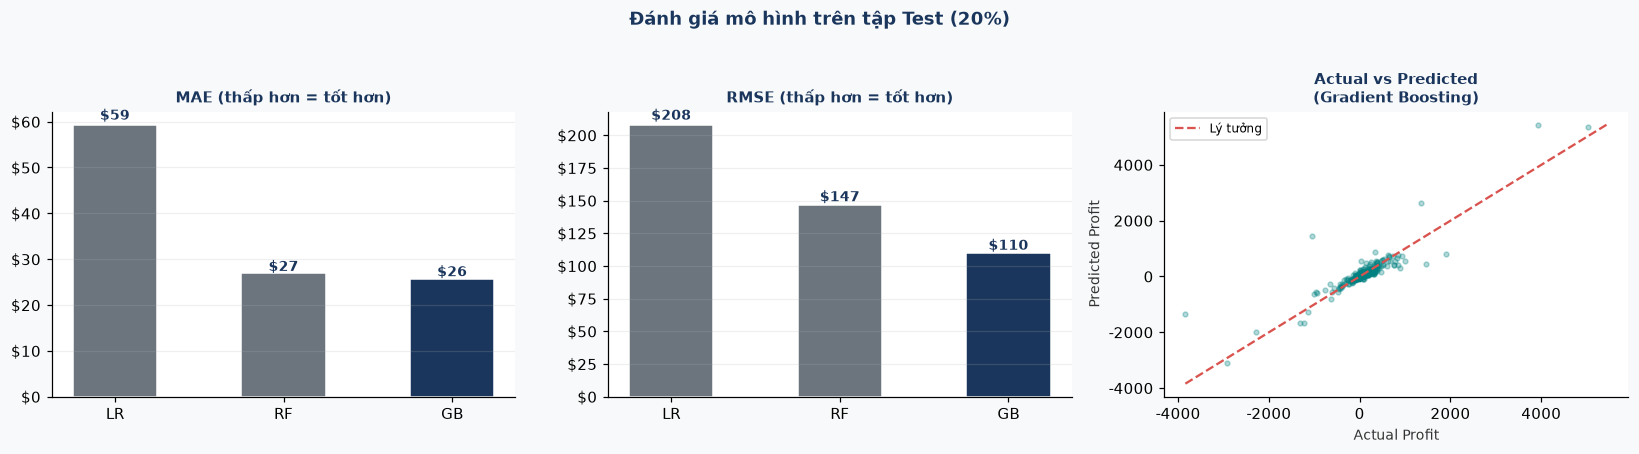

In [10]:
# Biểu đồ so sánh 3 mô hình + Actual vs Predicted
fig, axes = plt.subplots(1, 3, figsize=(15, 4), facecolor='#f8f9fa')

# Panel 1: MAE comparison
names_short = {'Linear Regression':'LR','Random Forest':'RF','Gradient Boosting':'GB'}
mnames = list(all_results.keys())
colors = [PALETTE['navy'] if n == best_name else PALETTE['grey'] for n in mnames]

for ax, metric, key in zip(axes[:2],
                             ['MAE (thấp hơn = tốt hơn)', 'RMSE (thấp hơn = tốt hơn)'],
                             ['test_mae', 'test_rmse']):
    vals = [all_results[n][key] for n in mnames]
    bars = ax.bar([names_short[n] for n in mnames], vals,
                  color=colors, width=0.5, edgecolor='white')
    ax.set_title(metric, fontweight='bold', fontsize=10, color=PALETTE['navy'])
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.2)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v:,.0f}'))
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
                f'${val:,.0f}', ha='center', fontsize=9, fontweight='bold',
                color=PALETTE['navy'])

# Panel 3: Actual vs Predicted (best model)
ax3 = axes[2]
y_pred_best = all_results[best_name]['test_pred']
ax3.scatter(y_test, y_pred_best, alpha=0.3, color=PALETTE['teal'], s=10)
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
ax3.plot(lims, lims, color=PALETTE['red'], lw=1.5, linestyle='--', label='Lý tưởng')
ax3.set_xlabel('Actual Profit', fontsize=9, color='#333333')
ax3.set_ylabel('Predicted Profit', fontsize=9, color='#333333')
ax3.set_title(f'Actual vs Predicted\n({best_name})',
              fontweight='bold', fontsize=10, color=PALETTE['navy'])
ax3.spines['top'].set_visible(False); ax3.spines['right'].set_visible(False)
ax3.legend(fontsize=8)

plt.suptitle('Đánh giá mô hình trên tập Test (20%)',
             fontweight='bold', fontsize=12, color=PALETTE['navy'], y=1.02)
plt.tight_layout(); plt.show()


In [11]:
# Bảng so sánh CV (Val) vs Test – phát hiện overfitting
print("=== BẢNG SO SÁNH VAL (CV) vs TEST – PHÁT HIỆN OVERFITTING ===\n")
compare_records = []
for n in mnames:
    cv_mae   = all_results[n]['avg_mae']
    test_mae = all_results[n]['test_mae']
    diff     = test_mae - cv_mae
    status   = '✅ Ổn định' if abs(diff)/cv_mae < 0.15 else '⚠️ Có thể overfit'
    compare_records.append({
        'Mô hình'    : n,
        'Val MAE (CV)': f"${cv_mae:,.2f}",
        'Test MAE'   : f"${test_mae:,.2f}",
        'Chênh lệch' : f"${diff:+,.2f}",
        'Trạng thái' : status,
    })
display(pd.DataFrame(compare_records))


=== BẢNG SO SÁNH VAL (CV) vs TEST – PHÁT HIỆN OVERFITTING ===



,Mô hình,Val MAE (CV),Test MAE,Chênh lệch,Trạng thái
0,Linear Regression,$58.38,$59.25,$+0.86,✅ Ổn định
1,Random Forest,$28.58,$26.90,$-1.69,✅ Ổn định
2,Gradient Boosting,$27.86,$25.77,$-2.09,✅ Ổn định


---
## 🔮 BƯỚC 5 – Dự báo Profit 3 tháng tới
*(Prediction & Deployment)*


In [12]:
# Re-train mô hình tốt nhất trên TOÀN BỘ dữ liệu (train + test)
best_pipe = all_results[best_name]['pipe']
best_pipe.fit(X, y)   # 100% data

# Tốc độ tăng trưởng
df['YearMonth'] = df['Order Date'].dt.to_period('M')
monthly = (df.groupby('YearMonth')
             .agg(Sales=('Sales','sum'), Profit=('Profit','sum'))
             .reset_index())
monthly['YM_str'] = monthly['YearMonth'].astype(str)

growth_rate      = monthly['Sales'].pct_change().dropna().tail(12).mean()
growth_rate      = max(growth_rate, 0.0)
base_month_sales = monthly['Sales'].iloc[-1]

cat_share = df.groupby('Category')['Sales'].sum() / df['Sales'].sum()
reg_share = df.groupby('Region')['Sales'].sum()   / df['Sales'].sum()

last_date       = df['Order Date'].max()
future_periods  = pd.date_range(start=last_date + pd.offsets.MonthBegin(1),
                                periods=3, freq='MS')
forecast_labels = [p.strftime('%Y-%m') for p in future_periods]

print(f"Mô hình dự báo: [{best_name}]")
print(f"Dự báo cho: {forecast_labels}")
print(f"Tốc độ tăng trưởng doanh thu/tháng: {growth_rate:.2%}")
print(f"Doanh thu cơ sở tháng cuối: ${base_month_sales:,.0f}")

def forecast_month(idx):
    month_sales = base_month_sales * (1 + growth_rate) ** idx
    rows = []
    for cat in cat_share.index:
        for reg in reg_share.index:
            seg = month_sales * cat_share[cat] * reg_share[reg]
            mask = (df['Category']==cat) & (df['Region']==reg)
            aov  = df.loc[mask,'Sales'].mean()
            n    = max(1, round(seg / aov))
            rows.append({'Sales'   : seg/n,
                         'Discount': df.loc[mask,'Discount'].mean(),
                         'Quantity': df.loc[mask,'Quantity'].mean(),
                         'Category': cat, 'Region': reg, '_n': n})
    sdf = pd.DataFrame(rows)
    profit = float((best_pipe.predict(sdf[FEATURES]) * sdf['_n'].values).sum())
    return {'Tháng': forecast_labels[idx-1],
            'Sales': month_sales, 'Profit': profit,
            'Margin': profit/month_sales*100}

fc_raw = [forecast_month(m) for m in range(1, 4)]


Mô hình dự báo: [Gradient Boosting]
Dự báo cho: ['2015-01', '2015-02', '2015-03']
Tốc độ tăng trưởng doanh thu/tháng: 11.37%
Doanh thu cơ sở tháng cuối: $90,475


In [13]:
# Bảng dự báo chi tiết
print("=== BẢNG DỰ BÁO PROFIT 3 THÁNG TỚI ===\n")
fc_display = pd.DataFrame([{
    'Tháng'             : r['Tháng'],
    'Doanh thu ước tính': f"${r['Sales']:,.0f}",
    'Lợi nhuận ước tính': f"${r['Profit']:,.0f}",
    'Biên LN (%)'       : f"{r['Margin']:.1f}%",
    'So tháng trước'    : ('—' if i==0 else
                           f"{(r['Profit']-fc_raw[i-1]['Profit'])/fc_raw[i-1]['Profit']*100:+.1f}%")
} for i, r in enumerate(fc_raw)])
display(fc_display)


=== BẢNG DỰ BÁO PROFIT 3 THÁNG TỚI ===



,Tháng,Doanh thu ước tính,Lợi nhuận ước tính,Biên LN (%),So tháng trước
0,2015-01,"$100,761","$10,198",10.1%,—
1,2015-02,"$112,217","$11,387",10.1%,+11.7%
2,2015-03,"$124,975","$12,578",10.1%,+10.5%


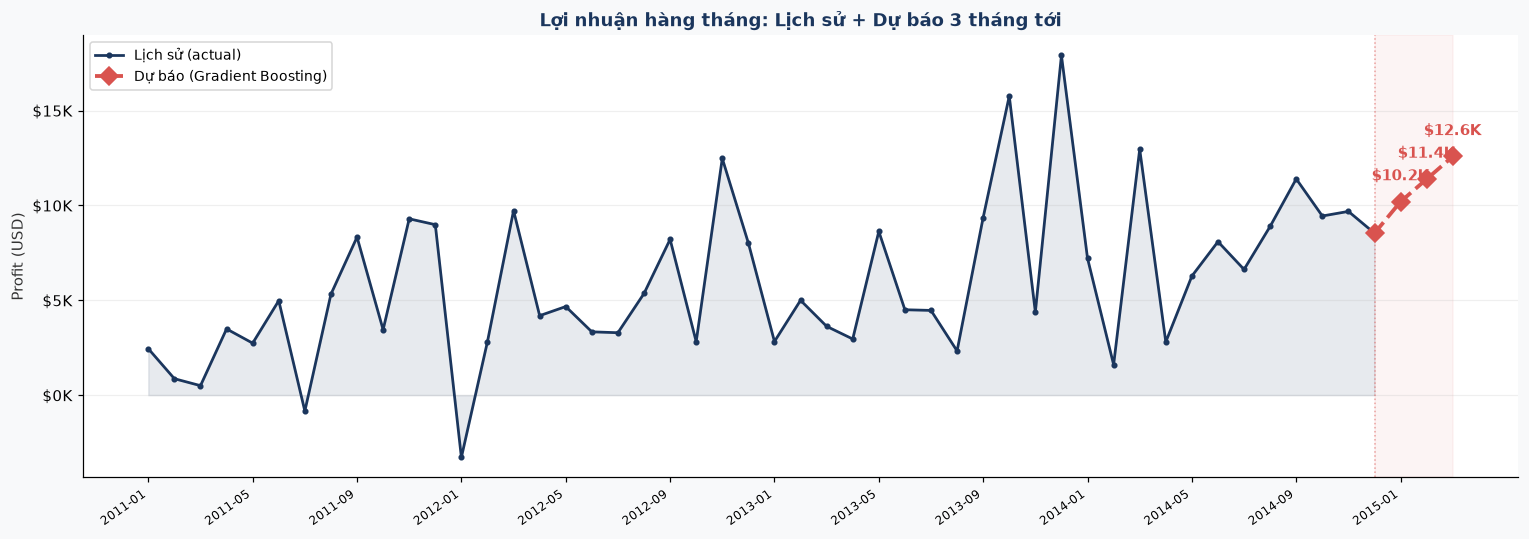

In [14]:
# Biểu đồ: Lịch sử + Dự báo
hist_profits = monthly['Profit'].tolist()
hist_labels  = monthly['YM_str'].tolist()
fc_profits   = [r['Profit'] for r in fc_raw]

fig, ax = plt.subplots(figsize=(14, 5), facecolor='#f8f9fa')
xs = range(len(hist_profits))
ax.fill_between(xs, hist_profits, alpha=0.1, color=PALETTE['navy'])
ax.plot(xs, hist_profits, color=PALETTE['navy'], lw=1.8,
        marker='o', ms=3, label='Lịch sử (actual)')

# Dự báo
xs_fc   = range(len(hist_profits)-1, len(hist_profits)+3)
connect = [hist_profits[-1]] + fc_profits
ax.plot(xs_fc, connect, color=PALETTE['red'], lw=2.5, marker='D', ms=8,
        linestyle='--', label=f'Dự báo ({best_name})', zorder=5)
for xp, vp in zip(list(xs_fc)[1:], fc_profits):
    ax.annotate(f'${vp/1e3:.1f}K', (xp, vp),
                textcoords='offset points', xytext=(0,14),
                ha='center', fontsize=10, fontweight='bold', color=PALETTE['red'])

# Vùng dự báo
ax.axvspan(len(hist_profits)-1, len(hist_profits)+2,
           alpha=0.06, color=PALETTE['red'])
ax.axvline(x=len(hist_profits)-1, color=PALETTE['red'],
           lw=1, linestyle=':', alpha=0.5)

all_labels = hist_labels + forecast_labels
step = max(1, len(all_labels)//12)
ax.set_xticks(range(0, len(all_labels), step))
ax.set_xticklabels([all_labels[i] for i in range(0, len(all_labels), step)],
                   rotation=35, ha='right', fontsize=8)
ax.set_title('Lợi nhuận hàng tháng: Lịch sử + Dự báo 3 tháng tới',
             fontweight='bold', fontsize=12, color=PALETTE['navy'])
ax.set_ylabel('Profit (USD)', fontsize=10, color='#333333')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v/1e3:.0f}K'))
ax.legend(fontsize=9, loc='upper left')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout(); plt.show()


---
## 📋 Tổng kết – Báo cáo 5 Bước


In [15]:
print("=" * 65)
print("  TỔNG KẾT 5 BƯỚC TRAINING AI – SUPERSTORE PROFIT FORECASTING")
print("=" * 65)

steps = [
    ("Bước 1", "Thu thập & Tiền xử lý",
     f"{len(df):,} mẫu · 5 features · StandardScaler + OHE"),
    ("Bước 2", "Chia Train/Test 80/20",
     f"Train: {len(X_train):,} mẫu | Test: {len(X_test):,} mẫu"),
    ("Bước 3", "Huấn luyện (5-Fold CV)",
     f"3 mô hình × 5 folds = 15 vòng huấn luyện"),
    ("Bước 4", "Đánh giá trên Test",
     f"Best: {best_name} · RMSE=${all_results[best_name]['test_rmse']:,.2f} · R²={all_results[best_name]['test_r2']:.4f}"),
    ("Bước 5", "Dự báo 3 tháng tới",
     " | ".join([f"{r['Tháng']}: ${r['Profit']:,.0f}" for r in fc_raw])),
]
for step, title, detail in steps:
    print(f"\n  ✅ {step} – {title}")
    print(f"     → {detail}")

print("\n" + "=" * 65)

# Bảng cuối
final_df = pd.DataFrame([
    {'Bước': s, 'Nội dung': t, 'Kết quả': d}
    for s, t, d in steps
])
display(final_df)


  TỔNG KẾT 5 BƯỚC TRAINING AI – SUPERSTORE PROFIT FORECASTING

  ✅ Bước 1 – Thu thập & Tiền xử lý
     → 9,994 mẫu · 5 features · StandardScaler + OHE

  ✅ Bước 2 – Chia Train/Test 80/20
     → Train: 7,995 mẫu | Test: 1,999 mẫu

  ✅ Bước 3 – Huấn luyện (5-Fold CV)
     → 3 mô hình × 5 folds = 15 vòng huấn luyện

  ✅ Bước 4 – Đánh giá trên Test
     → Best: Gradient Boosting · RMSE=$110.16 · R²=0.7785

  ✅ Bước 5 – Dự báo 3 tháng tới
     → 2015-01: $10,198 | 2015-02: $11,387 | 2015-03: $12,578



,Bước,Nội dung,Kết quả
0,Bước 1,Thu thập & Tiền xử lý,"9,994 mẫu · 5 features · StandardScaler + OHE"
1,Bước 2,Chia Train/Test 80/20,"Train: 7,995 mẫu | Test: 1,999 mẫu"
2,Bước 3,Huấn luyện (5-Fold CV),3 mô hình × 5 folds = 15 vòng huấn luyện
3,Bước 4,Đánh giá trên Test,Best: Gradient Boosting · RMSE=$110.16 · R²=0....
4,Bước 5,Dự báo 3 tháng tới,"2015-01: $10,198 | 2015-02: $11,387 | 2015-03:..."
